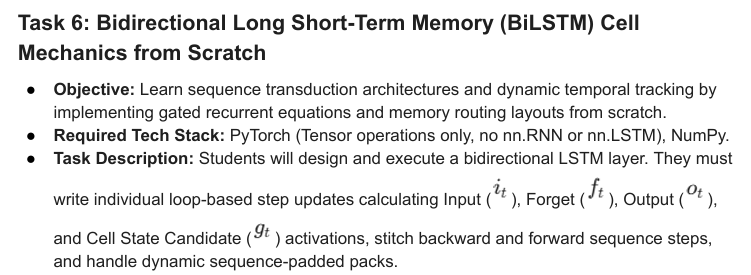

In [1]:
!pip install torch numpy matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)

sequence_length = 5
input_size = 3

X = torch.randn(
    sequence_length,
    input_size
)

print("Input shape:", X.shape)
print(X)

Input shape: torch.Size([5, 3])
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])


In [4]:
hidden_size = 4

In [5]:
W_forward = torch.randn(
    input_size + hidden_size,
    4 * hidden_size
) * 0.1

b_forward = torch.zeros(
    4 * hidden_size
)

In [6]:
W_backward = torch.randn(
    input_size + hidden_size,
    4 * hidden_size
) * 0.1

b_backward = torch.zeros(
    4 * hidden_size
)

In [7]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))


def tanh(x):
    return torch.tanh(x)

In [8]:
def lstm_step(
    x_t,
    h_prev,
    c_prev,
    W,
    b
):

    # Combine input and previous hidden state
    combined = torch.cat(
        [x_t, h_prev]
    )

    # Calculate all four components
    gates = combined @ W + b

    # Split into four parts
    i, f, o, g = torch.chunk(
        gates,
        4
    )

    # Activations
    i = sigmoid(i)
    f = sigmoid(f)
    o = sigmoid(o)
    g = tanh(g)

    # Cell state
    c = (
        f * c_prev
        +
        i * g
    )

    # Hidden state
    h = (
        o * tanh(c)
    )

    return h, c

In [9]:
h = torch.zeros(hidden_size)

c = torch.zeros(hidden_size)

In [10]:
x_t = X[0]

In [11]:
h, c = lstm_step(
    x_t,
    h,
    c,
    W_forward,
    b_forward
)

print("Hidden state:")
print(h)

print("\nCell state:")
print(c)

Hidden state:
tensor([-0.0073,  0.0203, -0.0272, -0.0042])

Cell state:
tensor([-0.0151,  0.0397, -0.0553, -0.0084])


In [12]:
def forward_lstm(
    X,
    W,
    b,
    hidden_size
):

    h = torch.zeros(hidden_size)
    c = torch.zeros(hidden_size)

    outputs = []

    for t in range(
        X.shape[0]
    ):

        h, c = lstm_step(
            X[t],
            h,
            c,
            W,
            b
        )

        outputs.append(h)

    return torch.stack(outputs)

In [13]:
forward_output = forward_lstm(
    X,
    W_forward,
    b_forward,
    hidden_size
)

print(
    "Forward output shape:",
    forward_output.shape
)

Forward output shape: torch.Size([5, 4])


In [14]:
def backward_lstm(
    X,
    W,
    b,
    hidden_size
):

    h = torch.zeros(hidden_size)
    c = torch.zeros(hidden_size)

    outputs = []

    for t in range(
        X.shape[0] - 1,
        -1,
        -1
    ):

        h, c = lstm_step(
            X[t],
            h,
            c,
            W,
            b
        )

        outputs.append(h)

    # Reverse back into original time order
    outputs.reverse()

    return torch.stack(outputs)

In [15]:
backward_output = backward_lstm(
    X,
    W_backward,
    b_backward,
    hidden_size
)

print(
    "Backward output shape:",
    backward_output.shape
)

Backward output shape: torch.Size([5, 4])


In [16]:
bilstm_output = torch.cat(
    [
        forward_output,
        backward_output
    ],
    dim=1
)

print(
    "BiLSTM output shape:",
    bilstm_output.shape
)

BiLSTM output shape: torch.Size([5, 8])


In [17]:
print("BiLSTM Output:")
print(bilstm_output)

BiLSTM Output:
tensor([[-0.0073,  0.0203, -0.0272, -0.0042, -0.0341, -0.0310, -0.0472, -0.0099],
        [-0.0123, -0.0275,  0.0198, -0.0379, -0.0309, -0.0488, -0.0798, -0.0497],
        [-0.0521,  0.0664, -0.0576, -0.0792, -0.1139, -0.0568, -0.0810,  0.0280],
        [-0.0247,  0.0586, -0.1036, -0.0481, -0.0305, -0.0198, -0.0288,  0.0028],
        [-0.0581,  0.0228, -0.0009, -0.0691, -0.0372, -0.0309, -0.0861, -0.0931]])


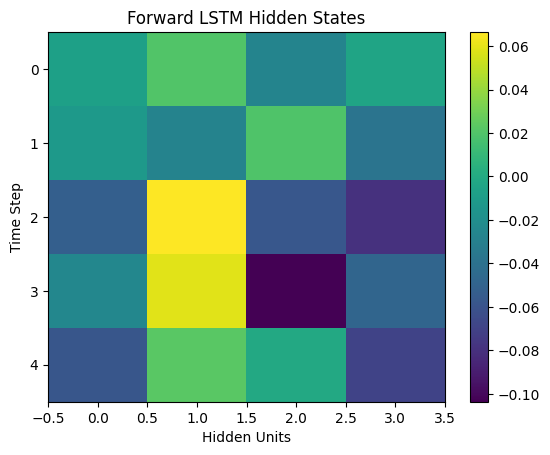

In [18]:
plt.imshow(
    forward_output.detach().numpy(),
    aspect="auto"
)

plt.xlabel("Hidden Units")
plt.ylabel("Time Step")

plt.title(
    "Forward LSTM Hidden States"
)

plt.colorbar()

plt.show()

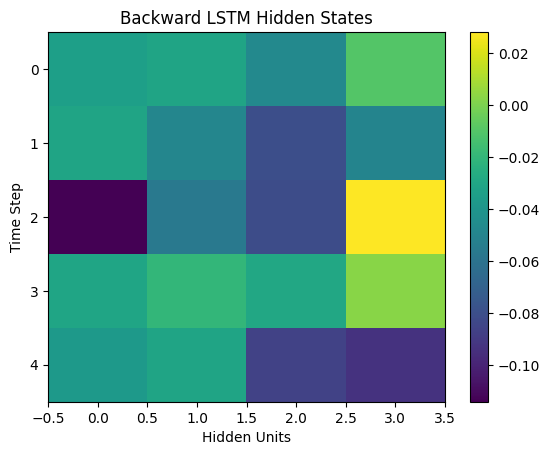

In [19]:
plt.imshow(
    backward_output.detach().numpy(),
    aspect="auto"
)

plt.xlabel("Hidden Units")
plt.ylabel("Time Step")

plt.title(
    "Backward LSTM Hidden States"
)

plt.colorbar()

plt.show()

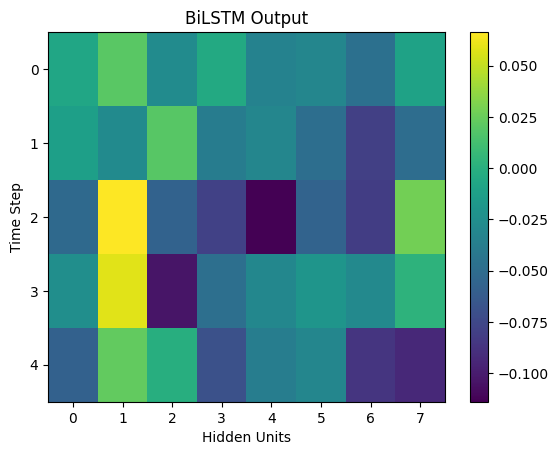

In [20]:
plt.imshow(
    bilstm_output.detach().numpy(),
    aspect="auto"
)

plt.xlabel("Hidden Units")
plt.ylabel("Time Step")

plt.title(
    "BiLSTM Output"
)

plt.colorbar()

plt.show()

In [21]:
output_size = 2

W_out = torch.randn(
    hidden_size * 2,
    output_size
) * 0.1

b_out = torch.zeros(
    output_size
)

In [22]:
final_representation = bilstm_output[-1]

logits = (
    final_representation @ W_out
    + b_out
)

probabilities = torch.softmax(
    logits,
    dim=0
)

print("Logits:")
print(logits)

print("\nProbabilities:")
print(probabilities)

Logits:
tensor([ 0.0125, -0.0144])

Probabilities:
tensor([0.5067, 0.4933])


In [23]:
prediction = torch.argmax(
    probabilities
)

print(
    "Predicted class:",
    prediction.item()
)

Predicted class: 0
